**Welcome to pyLIMA (v2) tutorial on parallax modelling!**

In this tutorial you will learn how adding different types of parallax models affect the fit. 

There are two types of parralax implemented in pyLIMA: **"Terrestrial"** parallax (due to distance from earths center) and **"Annual"** parallax (due to movement of earth). Both can be activated with the keyword **"Full"**.

You will test this on the simulated data from tutorial 3b.

In [121]:
### Import the required libraries.
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from pyLIMA.models import PSPL_model
from pyLIMA.fits import TRF_fit
from pyLIMA.outputs import pyLIMA_plots
### Import the simulator to be used for generating the simulated light curve
from pyLIMA.simulations import simulator

from pyLIMA import event

In [122]:
### Create an event.
your_event = event.Event(ra=270, dec=0)
your_event.name = 'My simulated event'

In [123]:
### Create some telescope(s) to observe the event from. This is exactly the same as in tutorial 3b.
### We will use CTIO_I (from Earth), Gaia_G and Spitzer_H (from Space).

CTIO_I = simulator.simulate_a_telescope(name='CTIO_I', time_start=2458365.5, time_end=2458965.5, sampling=4, location='Earth', camera_filter='I',
                                        uniform_sampling=False, altitude=1000, longitude = -109.285399, 
                                        latitude = -27.130, bad_weather_percentage=10.0 / 100, 
                                        moon_windows_avoidance=30, minimum_alt=30, astrometry=False)

SALT_I = simulator.simulate_a_telescope(name='SALT_I', time_start=2458365.5, time_end=2458965.5, sampling=8, location='Earth', camera_filter='I',
                                        uniform_sampling=False, altitude=1000, longitude = 20.8108, 
                                        latitude = +10.3758, bad_weather_percentage=5.0 / 100, 
                                        moon_windows_avoidance=30, minimum_alt=20, astrometry=False)

GAIA_G = simulator.simulate_a_telescope(name='GAIA_G', time_start=2458365.5, time_end=2458965.5, sampling=168, location='Space', camera_filter='G',
                                        uniform_sampling=True, spacecraft_name='Gaia', astrometry=False)

SPITZER_H = simulator.simulate_a_telescope(name='SPITZER_H', time_start=2458565.5, time_end=2458765.5, sampling=168, location='Space', camera_filter='H',
                                        uniform_sampling=True, spacecraft_name='Spitzer', astrometry=False)

your_event.telescopes.append(CTIO_I)
your_event.telescopes.append(SALT_I)
your_event.telescopes.append(GAIA_G)
your_event.telescopes.append(SPITZER_H)

### Run a quick sanity check on your input.
your_event.check_event()

 '2018-09-04T08:00:00.000' ... '2020-04-25T11:59:59.952'
 '2020-04-25T15:59:59.952' '2020-04-25T19:59:59.952'], location=(-1876359.2234166681, -5362421.234484145, -2891498.741933779) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron)> to <ICRS Frame>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]


check_event  : Everything looks fine...


 '2018-09-04T16:00:00.000' ... '2020-04-25T00:00:00.024'
 '2020-04-25T08:00:00.024' '2020-04-25T16:00:00.024'], location=(5866082.362847614, 2229581.0292909746, 1141340.0644664497) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron)> to <ICRS Frame>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]


Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope SALT_I: SUCCESS
Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS
Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope SALT_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS
Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS


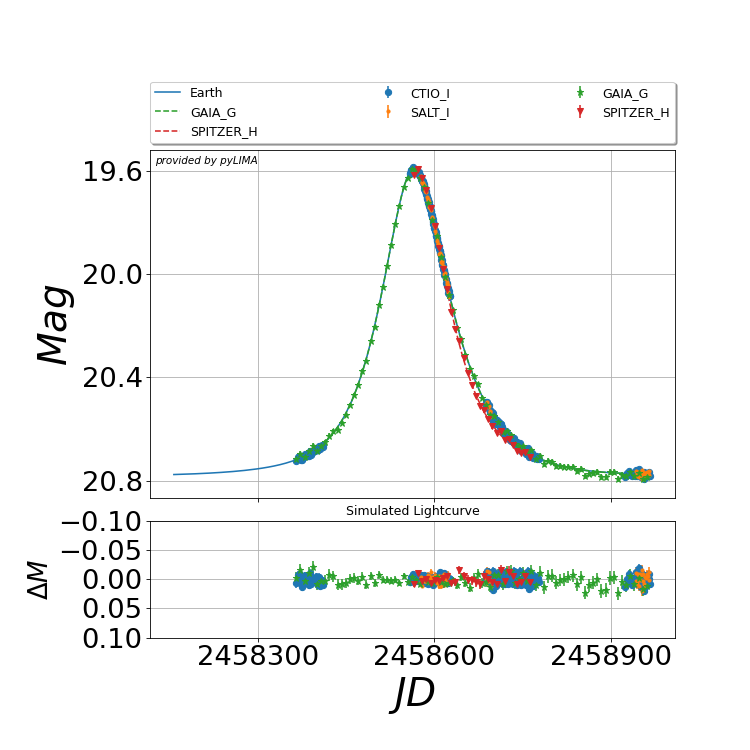

In [124]:
### For the simulation we use a PSPL-MODEL and add full parallax modelling.
### The reference date has to be close to t0.
pspl_sim = PSPL_model.PSPLmodel(your_event, parallax=['Full', 2458565.5])

### Set the relevant parameters.
# pspl_parameters = [to, uo, tE, flux_source, flux_blend]
pspl_parameters = simulator.simulate_microlensing_model_parameters(pspl_sim)

### Set the parameters to some reasonable values.
pspl_parameters[0] = 2458565.25 # t0
pspl_parameters[1:5] = [0.60, 81.50, 0.02, 0.07]

### Set the source and blend fluxes of all telescopes to the same values for plotting purposes.
n_tel = len(your_event.telescopes)
pspl_parameters[-n_tel*2::2] = 10000. * np.ones(n_tel) # source fluxes
pspl_parameters[-n_tel*2::2] = 1000. * np.ones(n_tel) # blend fluxes

### Transform the parameters into a pyLIMA class object.
pyLIMA_parameters_1 = pspl_sim.compute_pyLIMA_parameters(pspl_parameters)

### Inject everthing into the simulator to produce a light curve.
simulator.simulate_lightcurve(pspl_sim, pyLIMA_parameters_1)
pyLIMA_plots.plot_lightcurves(pspl_sim, pspl_parameters)
plt.title('Simulated Lightcurve')
plt.show()

### The lightcurves are saved in the object "my_event".

Selecting CTIO_I to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2458568.9372375575, 0.3509857022347953, 138.14574578699344, 433.16574697610787, 417.3598609908209, 419.4196263015969, 342.5534682865991, 426.02381992277753, 152.81265939933553, 446.6951064317216, 168.30163807237784]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2458567.5928126825)),
             ('u0', np.float64(0.4772481762918156)),
             ('tE', np.float64(97.0634924205432)),
             ('fsource_CTIO_I', np.float64(689.7600108607221)),
             ('ftotal_CTIO_I', np.float64(441.7766957613686)),
             ('fsource_SALT_I', np.float64(684.9300432454235)),
             ('ftotal_SALT_I', np.float64(355.95270045941584)),
             ('fsource_GAIA_G', np.float64(697.7394412324751)),
             ('ftotal_GAIA_G', np.float64(173.28314950671725)),
             ('fsource_SPITZER_H', np.float64(699.2527227808599)),
             ('ftotal

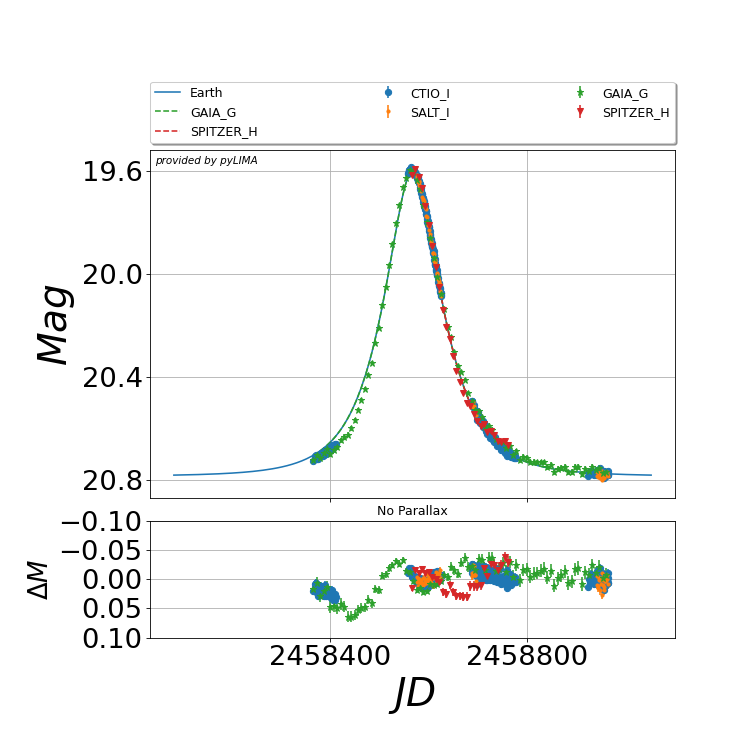

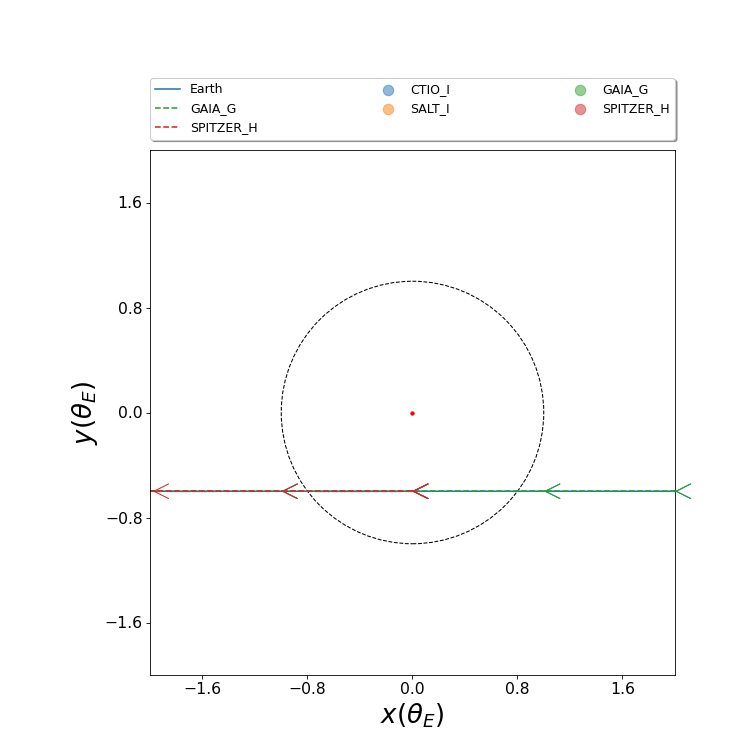

In [130]:
# Use a new pspl-model without parallax modelling and fit the lightcurves.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['None', 2458565.5])
my_fit = TRF_fit.TRFfit(pspl)
my_fit.fit()

# Plot the lightcurve.
pyLIMA_plots.plot_lightcurves(pspl, my_fit.fit_results['best_model'])
plt.title('No Parallax')
plt.show()
pyLIMA_plots.plot_geometry(pspl, pspl_parameters)
plt.show()

There is considerable mismatch between the data and the fitted lightcurve. Parallax modelling is needed here.

Parallax(Terrestrial) estimated for the telescope CTIO_I: SUCCESS
Parallax(Terrestrial) estimated for the telescope SALT_I: SUCCESS
Parallax(Terrestrial) estimated for the telescope GAIA_G: SUCCESS
Parallax(Terrestrial) estimated for the telescope SPITZER_H: SUCCESS


Selecting CTIO_I to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2458568.9372375575, 0.3509857022347953, 138.14574578699344, 0.0, 0.0, 433.16574697610787, 417.3598609908209, 419.4196263015969, 342.5534682865991, 426.02381992277753, 152.81265939933553, 446.6951064317216, 168.30163807237784]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2458567.5633050767)),
             ('u0', np.float64(0.4776864439471365)),
             ('tE', np.float64(97.37646815019819)),
             ('piEN', np.float64(0.016790543080003745)),
             ('piEE', np.float64(0.039061810105644426)),
             ('fsource_CTIO_I', np.float64(690.3391478483137)),
             ('ftotal_CTIO_I', np.float64(441.36322296235056)),
             ('fsource_SALT_I', np.float64(685.1922754627344)),
             ('ftotal_SALT_I', np.float64(355.6932712870734)),
             ('fsource_GAIA_G', np.float64(697.6978565566077)),
             ('ftotal_GAIA_

/home/jakob/miniconda3/envs/microlensing/lib/python3.14/site-packages/pyLIMA/fits/TRF_fit.py:32: RuntimeWarning: divide by zero encountered in log10
  scaling = 10**np.floor(np.log10(np.abs(self.guess)))+1


Parallax(Terrestrial) estimated for the telescope CTIO_I: SUCCESS
Parallax(Terrestrial) estimated for the telescope GAIA_G: SUCCESS
Parallax(Terrestrial) estimated for the telescope SPITZER_H: SUCCESS


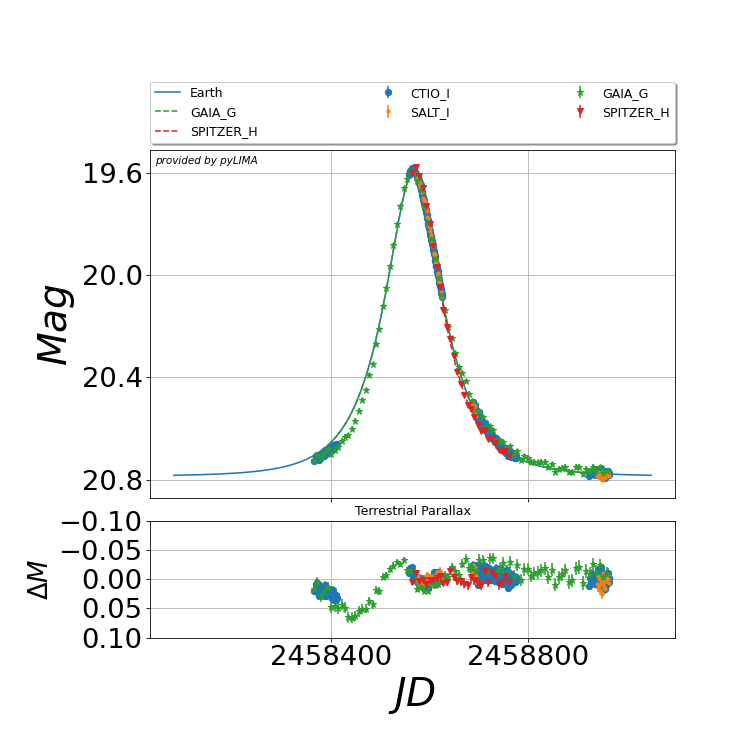

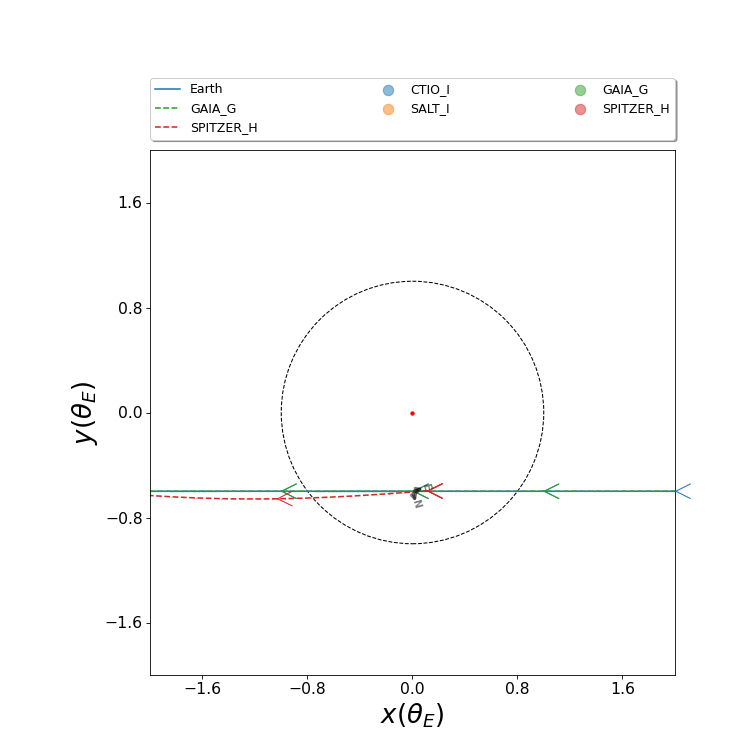

In [131]:
# Now we try this with terrestrial parallax modelling.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Terrestrial', 2458565.5])
my_fit = TRF_fit.TRFfit(pspl)
my_fit.fit()

# Plot the lightcurve.
pyLIMA_plots.plot_lightcurves(pspl, my_fit.fit_results['best_model'])
plt.title('Terrestrial Parallax')
plt.show()
pyLIMA_plots.plot_geometry(pspl, pspl_parameters)
plt.show()

Terrestrial parrallax modelling doesn't result in a visible difference. Parallax due to different distances from the earths center can be neglected.

Parallax(Annual) estimated for the telescope CTIO_I: SUCCESS
Parallax(Annual) estimated for the telescope SALT_I: SUCCESS
Parallax(Annual) estimated for the telescope GAIA_G: SUCCESS
Parallax(Annual) estimated for the telescope SPITZER_H: SUCCESS
Selecting CTIO_I to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2458568.9372375575, 0.3509857022347953, 138.14574578699344, 0.0, 0.0, 433.16574697610787, 417.3598609908209, 419.4196263015969, 342.5534682865991, 426.02381992277753, 152.81265939933553, 446.6951064317216, 168.30163807237784]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2458565.1300703944)),
             ('u0', np.float64(0.5963058492859801)),
             ('tE', np.float64(81.99293531980629)),
             ('piEN', np.float64(0.019959393726819406)),
             ('piEE', np.float64(0.07159798615173674)),
             ('fsource_CTIO_I', np.float64(991.7880614575097)),
             ('ftotal_CTIO_I', np.fl

/home/jakob/miniconda3/envs/microlensing/lib/python3.14/site-packages/pyLIMA/fits/TRF_fit.py:32: RuntimeWarning: divide by zero encountered in log10
  scaling = 10**np.floor(np.log10(np.abs(self.guess)))+1


Parallax(Annual) estimated for the telescope CTIO_I: SUCCESS
Parallax(Annual) estimated for the telescope GAIA_G: SUCCESS
Parallax(Annual) estimated for the telescope SPITZER_H: SUCCESS


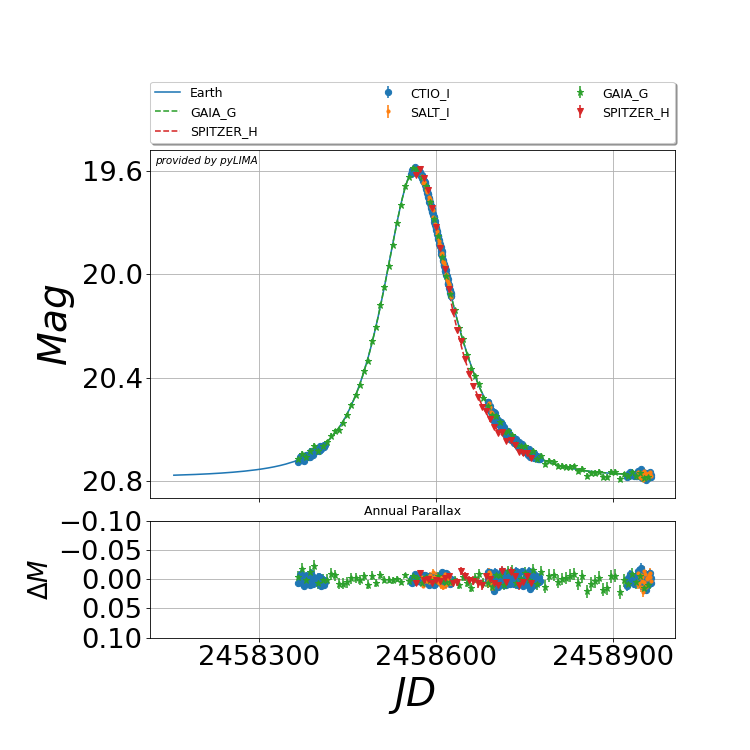

In [127]:
# Now with an annual parallax.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Annual', 2458565.5])
my_fit = TRF_fit.TRFfit(pspl)
my_fit.fit()

# Plot the lightcurve.
pyLIMA_plots.plot_lightcurves(pspl, my_fit.fit_results['best_model'])
plt.title('Annual Parallax')
plt.show()

Adding an annual parallax model to the pspl model drastically improves the accuracy of the fit. The movement of the earth around the sun is the important parallax effect here.

Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope SALT_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS
Selecting CTIO_I to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2458568.9372375575, 0.3509857022347953, 138.14574578699344, 0.0, 0.0, 433.16574697610787, 417.3598609908209, 419.4196263015969, 342.5534682865991, 426.02381992277753, 152.81265939933553, 446.6951064317216, 168.30163807237784]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2458565.1300703944)),
             ('u0', np.float64(0.5963058492859801)),
             ('tE', np.float64(81.99293531980629)),
             ('piEN', np.float64(0.019959393726819406)),
             ('piEE', np.float64(0.07159798615173674)),
             ('fsource_CTIO_I', np.float64(991.7880614575097)),
             ('ftotal_CTIO_I', np.float64(44

/home/jakob/miniconda3/envs/microlensing/lib/python3.14/site-packages/pyLIMA/fits/TRF_fit.py:32: RuntimeWarning: divide by zero encountered in log10
  scaling = 10**np.floor(np.log10(np.abs(self.guess)))+1


Parallax(Full) estimated for the telescope CTIO_I: SUCCESS
Parallax(Full) estimated for the telescope GAIA_G: SUCCESS
Parallax(Full) estimated for the telescope SPITZER_H: SUCCESS


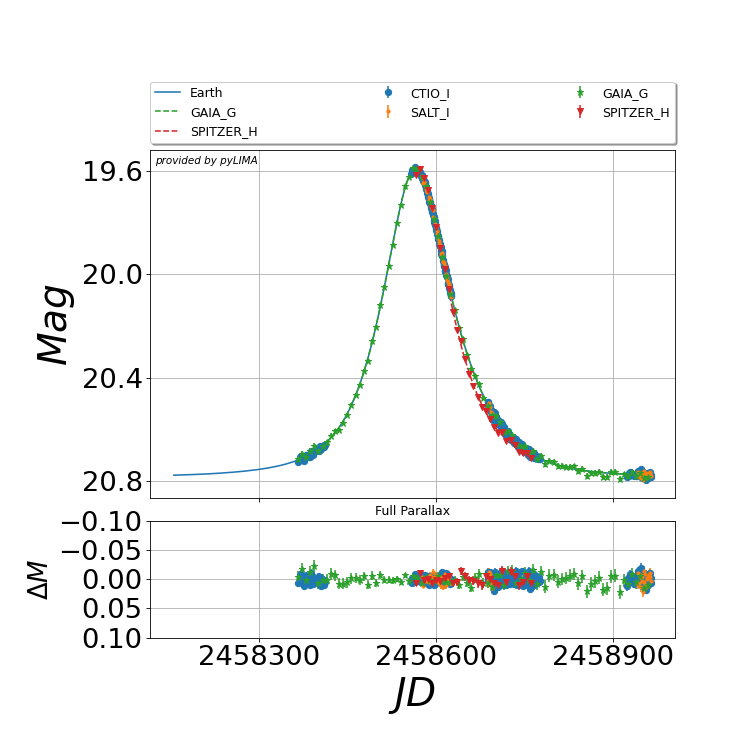

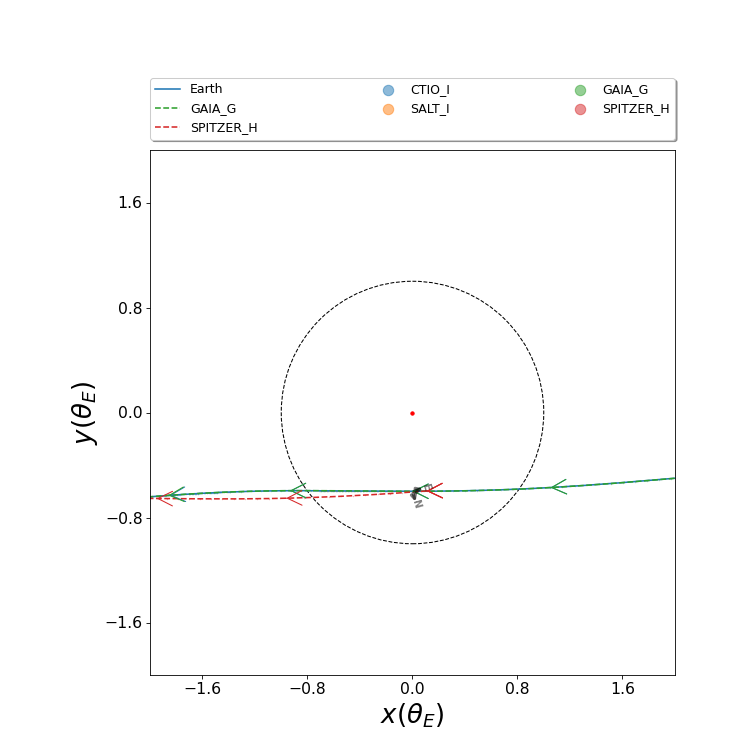

In [129]:
# And with full (annual & terrestrial) parallax modelling.
pspl = PSPL_model.PSPLmodel(your_event, parallax=['Full', 2458565.5])
my_fit = TRF_fit.TRFfit(pspl)
my_fit.fit()

# Plot the lightcurve.
pyLIMA_plots.plot_lightcurves(pspl, my_fit.fit_results['best_model'])
plt.title('Full Parallax')
plt.show()
pyLIMA_plots.plot_geometry(pspl, pspl_parameters)
plt.show()

Full parallax modelling includes a terrestrial and an annual parallax.